In [211]:
import slangpy
from pathlib import Path
import matplotlib.pyplot as plt
import os 
cwd = Path(os.getcwd())

In [212]:
device = slangpy.create_device(slangpy.DeviceType.vulkan)
program = (cwd / "CSPrecompute.slang").as_posix()    

integrateGGX_E = device.create_compute_kernel(device.load_program(program, ["integrateGGX_E"]))    
integrateGGX_Eavg = device.create_compute_kernel(device.load_program(program, ["integrateGGX_Eavg"]))

ggx_E = device.create_buffer(element_count=32*32, struct_size=4, format=slangpy.Format.r32_float, usage=slangpy.BufferUsage.unordered_access)
ggx_Eavg = device.create_buffer(element_count=32, struct_size=4, format=slangpy.Format.r32_float, usage=slangpy.BufferUsage.unordered_access)

integrateGGX_E.dispatch(thread_count=[1,1,1],vars={"output": ggx_E})
integrateGGX_Eavg.dispatch(thread_count=[1,1,1],vars={"output": ggx_Eavg})

[INFO] (rhi) layer: CreateDevice: Debug layer is enabled.
[WARN] Slang compiler warnings:
/home/mos9527/Foundation/Scripts/../Editor/Shaders/IBRDF.slang(161): warning 41018: returning without initializing out parameter 'wt'
        return false;
        ^~~~~~
/home/mos9527/Foundation/Scripts/../Editor/Shaders/IBRDF.slang(161): warning 41018: returning without initializing out parameter 'etap'
        return false;
        ^~~~~~



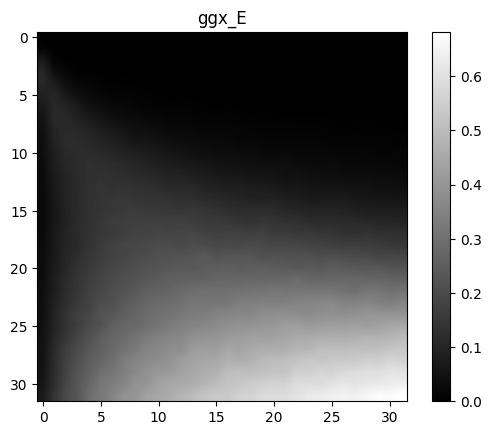

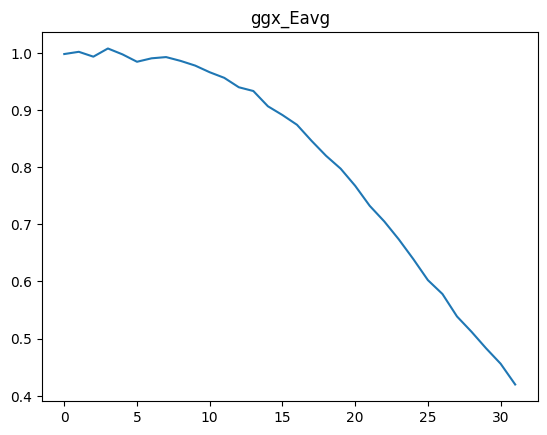

In [213]:
# E (1-E)
im_ggx_E = ggx_E.to_numpy().reshape((32,32))
plt.imshow(im_ggx_E, cmap='gray', interpolation='bilinear')
plt.title('ggx_E')
plt.colorbar()
plt.show()
# Eavg
im_ggx_Eavg = ggx_Eavg.to_numpy()
plt.plot(im_ggx_Eavg)
plt.title('ggx_Eavg')
plt.show()


In [214]:
# Dump it.
# We don't use image containers for this as this would be uploaded back to GPU anyway
print("static const float ggx_E[32 * 32] = {\n\t",end='')
for i, v in enumerate(ggx_E.to_numpy()):
    print(f"{v:.6f}f,", end=' ' if (i+1) % 32 else '\n\t')
print("\n};")

static const float ggx_E[32 * 32] = {
	0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f,
	0.012020f, 0.001243f, 0.000451f, 0.000101f, 0.000060f, 0.000041f, 0.000272f, 0.000021f, 0.000016f, 0.000013f, 0.000010f, 0.000008f, 0.000007f, 0.000006f, 0.000005f, 0.000004f, 0.000003f, 0.000003f, 0.000002f, 0.000002f, 0.000002f, 0.000001f, 0.000001f, 0.000001f, 0.000001f, 0.000001f, 0.000001f, 0.000000f, 0.000000f, 0.000000f, 0.000000f, 0.000000f,
	0.067098f, 0.010587f, 0.002934f, 0.002322f, 0.000890f, 0.000505f, 0.000476f, 0.000163f, 0.000130f, 0.000098f, 0.000810f, 0.000307f, 0.000052f, 0.000043f, 0.000036f, 0.000275f, 0.000026f, 0.000266f, 0.000019f, 0.000016f, 0.000013f, 0.000256f, 0.000010f, 0.

In [215]:
print("static const float ggx_Eavg[32] = {\n\t",end='')
for v in ggx_Eavg.to_numpy():
    print(f"{v:.6f}f,", end=' ')
print("\n};")

static const float ggx_Eavg[32] = {
	0.997890f, 1.001792f, 0.993288f, 1.007621f, 0.997338f, 0.984380f, 0.990408f, 0.992566f, 0.985874f, 0.977681f, 0.966028f, 0.956247f, 0.939775f, 0.933182f, 0.906508f, 0.891165f, 0.874091f, 0.846053f, 0.819791f, 0.797357f, 0.767349f, 0.732302f, 0.705049f, 0.673594f, 0.639023f, 0.602280f, 0.578066f, 0.538744f, 0.511916f, 0.482994f, 0.456039f, 0.419730f, 
};
